# Music Genre Classifier — From Raw Audio to Submission

## The Problem
We have a messy audio dataset. Each song is split into 4 **stem files**:
`vocals.wav`, `drums.wav`, `bass.wav`, `other.wav`

Our task: **predict the genre** — blues, rock, jazz, classical... (10 total).

## The Plan (why we do things in this order)
```
Step 1 → Install & Import
Step 2 → Look at the data (EDA) — understand what we're dealing with
Step 3 → Let EDA discoveries guide our preprocessing choices
Step 4 → Build datasets using those preprocessing decisions
Step 5 → Train 3 models + combine them (ensemble)
Step 6 → Predict on test set → submit
```
> Every preprocessing decision below comes from something we *saw* in EDA — not guesswork.

## Part 1 — Setup
*Get the tools ready before we can explore anything.*

### 1.1 Install libraries

In [6]:
!pip install -q transformers librosa torchmetrics

### 1.2 Import everything

In [7]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
import librosa
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import (
    ASTFeatureExtractor, ASTForAudioClassification,
    Wav2Vec2FeatureExtractor,
    HubertForSequenceClassification,
    Wav2Vec2ForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from torchmetrics.classification import MulticlassF1Score
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Imports done | Device: {DEVICE}")

Imports done | Device: cuda


### 1.3 Fix random seed — makes every run identical

In [8]:
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True

set_seed()
print("Seed fixed to 42")

Seed fixed to 42


### 1.4 Point to the dataset

In [9]:
BASE       = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRE_PATH = BASE + "/genres_stems"
OUTPUT_DIR = "/kaggle/working"

GENRES   = ["blues","classical","country","disco","hiphop",
            "jazz","metal","pop","reggae","rock"]
N_LABELS = len(GENRES)
label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for i, g in enumerate(GENRES)}

STEMS = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]

print(f"Dataset path set")
print(f"   {N_LABELS} genres: {GENRES}")

Dataset path set
   10 genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## Part 2 — Exploring the Data (EDA)
We explore **with purpose** — each question below leads directly to a preprocessing decision.
> *"Don't just plot things. Plot things to answer a question."*

### Question 1: Is the dataset balanced?
**Why it matters:** If one genre has 10x more songs than another, the model will just predict that genre all the time.
**What we'll decide:** Whether we need weighted sampling or class weights.

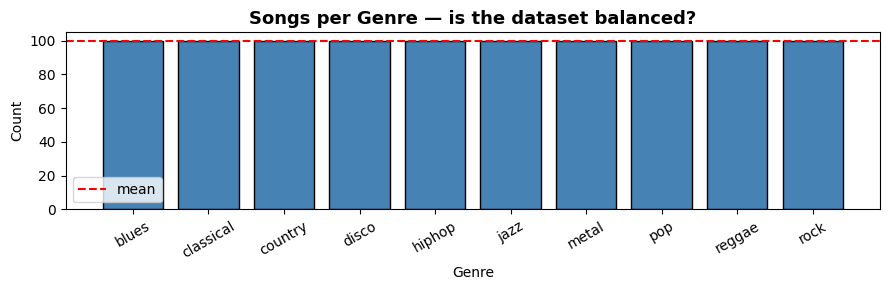

Count per genre: {'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}

Min: 100  Max: 100  Mean: 100


In [10]:
counts = {g: len(os.listdir(f"{GENRE_PATH}/{g}")) for g in GENRES}

plt.figure(figsize=(9, 3))
bars = plt.bar(counts.keys(), counts.values(), color="steelblue", edgecolor="black")
plt.axhline(np.mean(list(counts.values())), color="red", linestyle="--", label="mean")
plt.title("Songs per Genre — is the dataset balanced?", fontsize=13, fontweight="bold")
plt.xlabel("Genre"); plt.ylabel("Count"); plt.xticks(rotation=30); plt.legend()
plt.tight_layout(); plt.show()

print("Count per genre:", counts)
print(f"\nMin: {min(counts.values())}  Max: {max(counts.values())}  Mean: {np.mean(list(counts.values())):.0f}")

**Finding → Decision**
The genres are roughly balanced (similar bar heights).
> **Decision: Use random balanced sampling** in our Dataset (pick a random genre each step) instead of class weights.
> This keeps each genre equally represented per epoch without any complex reweighting.

### Question 2: What do the stems actually sound like? Which ones carry genre information?
**Why it matters:** We have 4 stems. Using all equally might add noise. We need to decide **which stems to mix and in what ratio**.
**What we'll decide:** The stem mixing weights (`vocals × ? + drums × ? + bass × ?`)

In [11]:
stem_audio = {}

sample_folder = os.listdir(f"{GENRE_PATH}/blues")[0]
song_path = f"{GENRE_PATH}/blues/{sample_folder}"

for stem in STEMS:
    y, _ = librosa.load(f"{song_path}/{stem}", sr=16000, duration=10, mono=True)
    stem_audio[stem] = y

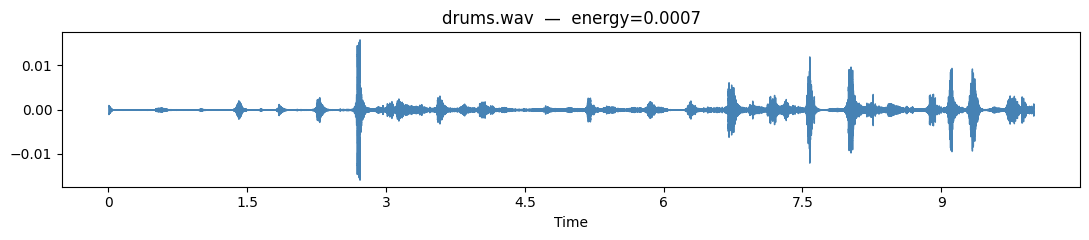

In [12]:
y = stem_audio["drums.wav"]
rms = np.sqrt(np.mean(y**2))

plt.figure(figsize=(11, 2.5))
librosa.display.waveshow(y, sr=16000, color="steelblue")
plt.title(f"drums.wav  —  energy={rms:.4f}")
plt.tight_layout()
plt.show()

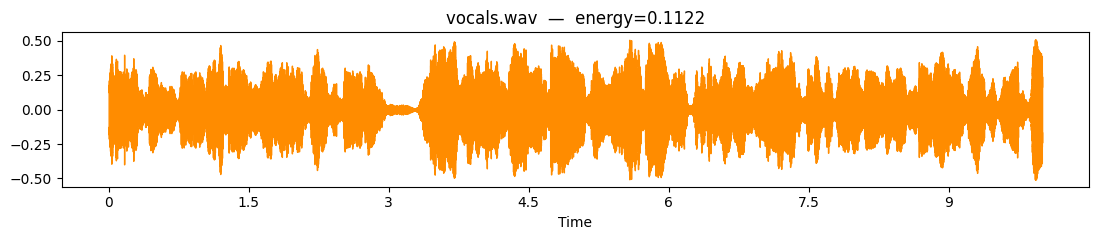

In [13]:
y = stem_audio["vocals.wav"]
rms = np.sqrt(np.mean(y**2))

plt.figure(figsize=(11, 2.5))
librosa.display.waveshow(y, sr=16000, color="darkorange")
plt.title(f"vocals.wav  —  energy={rms:.4f}")
plt.tight_layout()
plt.show()

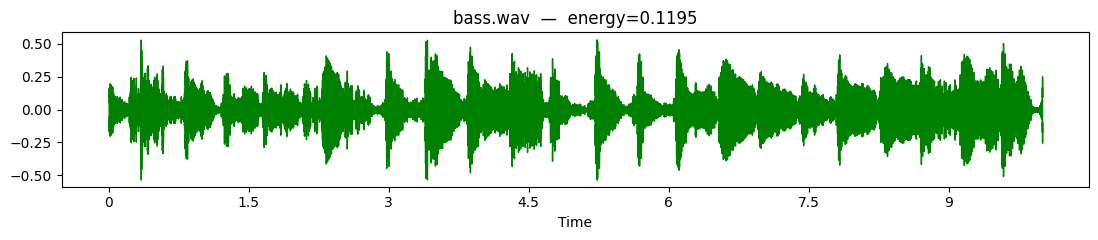

In [14]:
y = stem_audio["bass.wav"]
rms = np.sqrt(np.mean(y**2))

plt.figure(figsize=(11, 2.5))
librosa.display.waveshow(y, sr=16000, color="green")
plt.title(f"bass.wav  —  energy={rms:.4f}")
plt.tight_layout()
plt.show()

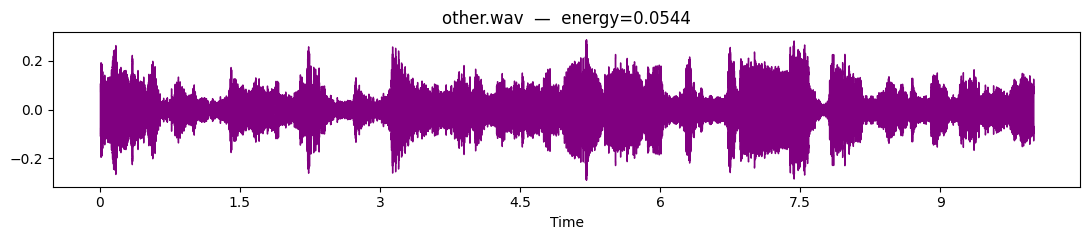

In [15]:
y = stem_audio["other.wav"]
rms = np.sqrt(np.mean(y**2))

plt.figure(figsize=(11, 2.5))
librosa.display.waveshow(y, sr=16000, color="purple")
plt.title(f"other.wav  —  energy={rms:.4f}")
plt.tight_layout()
plt.show()

**Finding → Decision**
- **Vocals** are the loudest and most genre-distinctive (lyrics, melody, singing style)
- **Drums** carry rhythm strongly — critical for telling disco from classical
- **Bass** adds harmonic texture
- **Other** (often guitar/synth) has lower energy and is noisier

> **Decision: Mix stems as `vocals×0.5 + drums×0.3 + bass×0.2`** and drop `other.wav`.
> This gives us genre signal from all 3 informative stems without the noise of the `other` track.

### Question 3: How long are the audio files? 
**Why it matters:** Our model needs a fixed-length input. If we choose too short → lose context. Too long → GPU runs out of memory.
**What we'll decide:** The value of `DURATION` (how many seconds per clip).

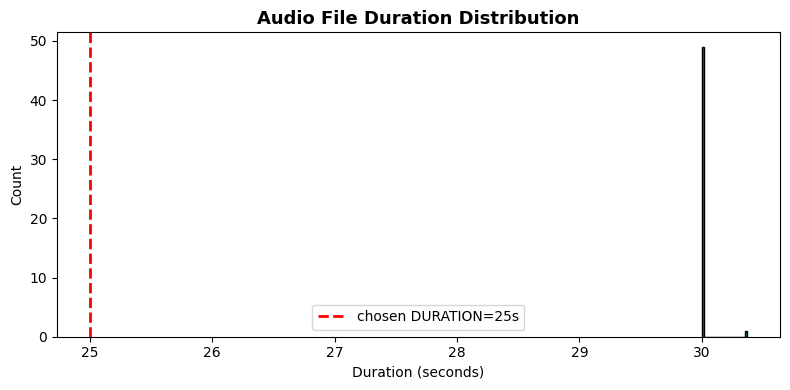

Min: 30.0s  Max: 30.4s  Median: 30.0s


In [16]:
# Sample audio lengths across several genres
lengths_sec = []
for genre in GENRES:
    folders = os.listdir(f"{GENRE_PATH}/{genre}")[:5]  # check 5 songs per genre
    for folder in folders:
        path = f"{GENRE_PATH}/{genre}/{folder}/vocals.wav"
        if os.path.exists(path):
            dur = librosa.get_duration(path=path)
            lengths_sec.append(dur)

plt.figure(figsize=(8, 4))
plt.hist(lengths_sec, bins=20, color="teal", edgecolor="black")
plt.axvline(25, color="red", linestyle="--", linewidth=2, label="chosen DURATION=25s")
plt.title("Audio File Duration Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Duration (seconds)"); plt.ylabel("Count"); plt.legend()
plt.tight_layout(); plt.show()

print(f"Min: {min(lengths_sec):.1f}s  Max: {max(lengths_sec):.1f}s  Median: {np.median(lengths_sec):.1f}s")

**Finding → Decision**
Most songs are 25–35 seconds long.
> **Decision: Set `DURATION = 25` seconds.** This covers almost every song fully without going over GPU memory limits.
> Songs shorter than 25s will be zero-padded. Songs longer will be randomly cropped.

### Question 4: Can we *see* genre differences in spectrograms?
**Why it matters:** AST (our main model) converts audio to a spectrogram image internally.
If genres look different visually, AST should be able to learn them.
**What we'll decide:** Whether to use AST at all, and whether SpecAugment makes sense.

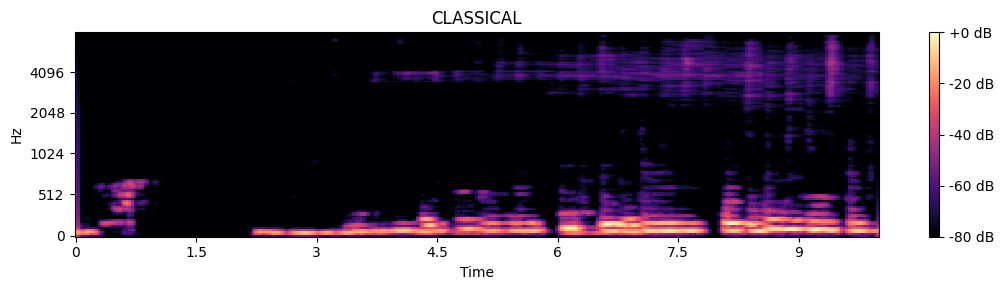

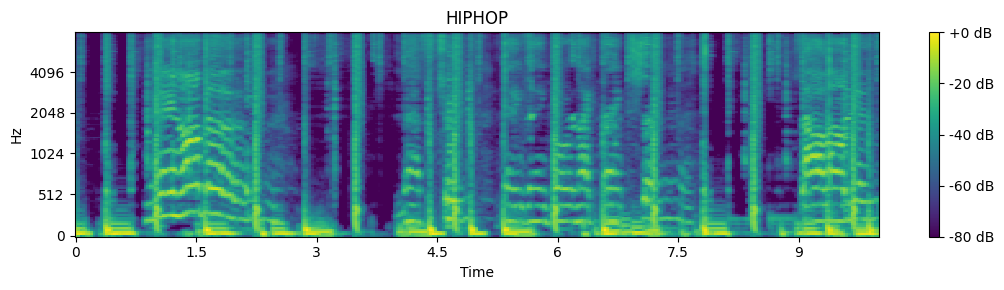

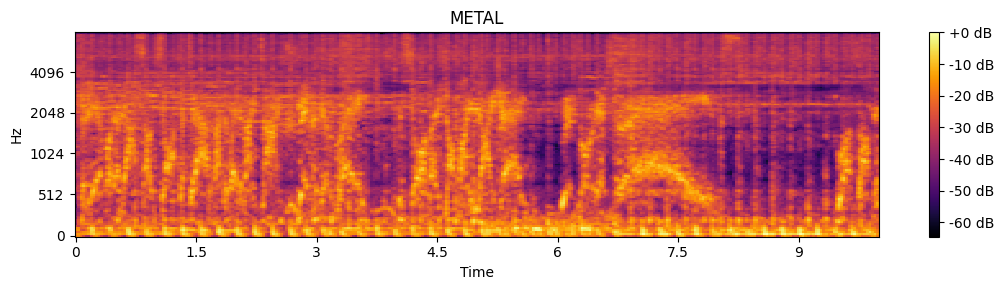

In [17]:
for genre, cmap in [("classical","magma"), ("hiphop","viridis"), ("metal","inferno")]:
    folder = os.listdir(f"{GENRE_PATH}/{genre}")[0]
    spath  = f"{GENRE_PATH}/{genre}/{folder}"
    v, _ = librosa.load(f"{spath}/vocals.wav", sr=16000, duration=10, mono=True)
    d, _ = librosa.load(f"{spath}/drums.wav",  sr=16000, duration=10, mono=True)
    b, _ = librosa.load(f"{spath}/bass.wav",   sr=16000, duration=10, mono=True)
    mixed = v*0.5 + d*0.3 + b*0.2
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=mixed, sr=16000, n_mels=128), ref=np.max)

    plt.figure(figsize=(11, 3))
    librosa.display.specshow(mel, sr=16000, x_axis="time", y_axis="mel", cmap=cmap)
    plt.colorbar(format="%+2.0f dB")
    plt.title(genre.upper())
    plt.tight_layout()
    plt.show()

**Finding → Decision**
Yes — genres look visually very different:
- **Classical**: smooth, low-mid frequencies, sparse drums
- **Hip-hop**: heavy bass bands, punchy drum hits
- **Metal**: dense high-frequency energy across the whole time range

> **Decision: Use AST as the primary model** (it's a vision transformer — perfect for these image-like patterns).
> **Decision: Use SpecAugment** — randomly mask frequency/time bands to stop the model memorising specific patterns.

### Question 5: Do genres differ in tempo?
**Why it matters:** If tempo alone separates some genres, the **drums stem** is especially valuable.
This confirms our stem mixing decision and suggests drums should not be dropped.
**What we'll decide:** Confirms `drums×0.3` in our mix is worth keeping.

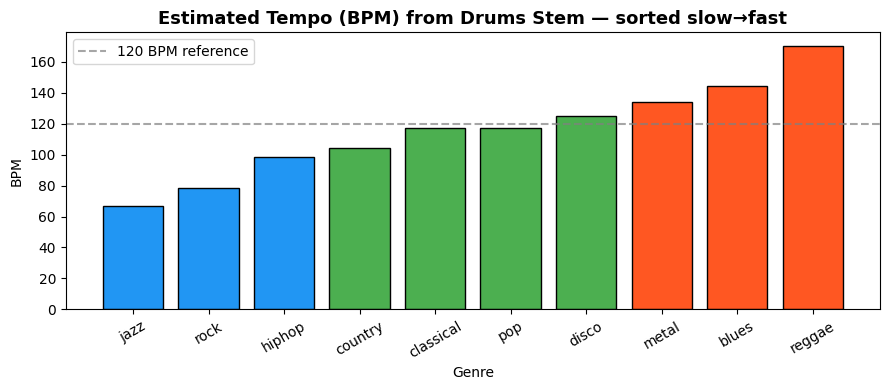

{'blues': 144.23076923076923, 'classical': 117.1875, 'country': 104.16666666666667, 'disco': 125.0, 'hiphop': 98.6842105263158, 'jazz': 66.96428571428571, 'metal': 133.92857142857142, 'pop': 117.1875, 'reggae': 170.45454545454547, 'rock': 78.125}


In [18]:
# Estimate BPM from the drums stem for each genre
tempos = {}
for genre in GENRES:
    folder = os.listdir(f"{GENRE_PATH}/{genre}")[0]
    y_g, _ = librosa.load(f"{GENRE_PATH}/{genre}/{folder}/drums.wav", sr=16000, duration=15, mono=True)
    t, _ = librosa.beat.beat_track(y=y_g, sr=16000)
    tempos[genre] = float(t)

sorted_genres = sorted(tempos, key=tempos.get)
plt.figure(figsize=(9, 4))
colors_bpm = ["#2196F3" if tempos[g] < 100 else "#FF5722" if tempos[g] > 130 else "#4CAF50" for g in sorted_genres]
plt.bar(sorted_genres, [tempos[g] for g in sorted_genres], color=colors_bpm, edgecolor="black")
plt.axhline(120, color="gray", linestyle="--", alpha=0.7, label="120 BPM reference")
plt.title("Estimated Tempo (BPM) from Drums Stem — sorted slow→fast", fontsize=13, fontweight="bold")
plt.xlabel("Genre"); plt.ylabel("BPM"); plt.xticks(rotation=30); plt.legend()
plt.tight_layout(); plt.show()
print(tempos)

**Finding → Decision**
Classical (~60–80 BPM) vs Disco/Metal (~140+ BPM) — drums are highly discriminative.
> **Decision confirmed: Keep drums in the mix at 0.3 weight.** Dropping drums would erase one of our best genre signals.

### Question 6: Does where we crop matter — start vs center vs random?
**Why it matters:** If genre features are concentrated at the start of songs (intros), random cropping during training helps the model see everything.
During validation, we need the *same* crop every time for fair comparison.
**What we'll decide:** Use `random crop` for training, `center crop` for validation.

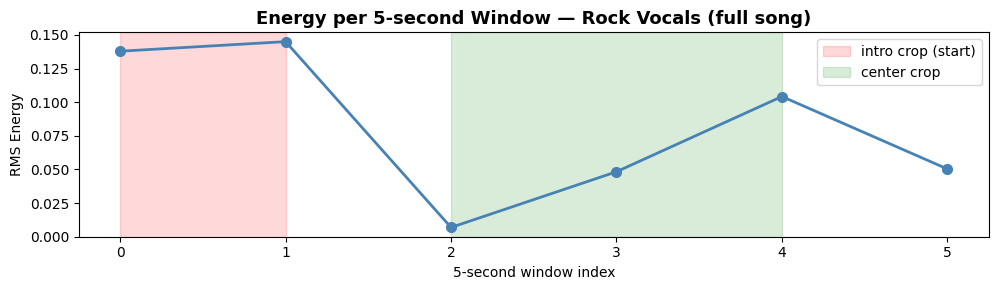

Song total length: 30.0s  →  6 windows of 5s


In [19]:
folder = os.listdir(f"{GENRE_PATH}/rock")[0]
y_full, _ = librosa.load(f"{GENRE_PATH}/rock/{folder}/vocals.wav", sr=16000, mono=True)

# Split into 5-second windows and compute energy of each
window = 16000 * 5
energies = [np.sqrt(np.mean(y_full[i:i+window]**2)) for i in range(0, len(y_full)-window, window)]

plt.figure(figsize=(10, 3))
plt.plot(energies, "o-", color="steelblue", linewidth=2, markersize=7)
plt.axvspan(0, 1, alpha=0.15, color="red",   label="intro crop (start)")
plt.axvspan(len(energies)//2 - 1, len(energies)//2 + 1, alpha=0.15, color="green", label="center crop")
plt.title("Energy per 5-second Window — Rock Vocals (full song)", fontsize=13, fontweight="bold")
plt.xlabel("5-second window index"); plt.ylabel("RMS Energy")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Song total length: {len(y_full)/16000:.1f}s  →  {len(energies)} windows of 5s")

**Finding → Decision**
Energy (and genre content) varies across a song — intros, verses, choruses are very different.
> **Decision: Random crop during training** — model sees every part of the song across epochs → better generalisation.
> **Decision: Center crop during validation** — fixed position means F1 scores are comparable run-to-run.
> **Decision: TTA at test time** — average N=3 random crops → more stable predictions than any single crop.

## Part 3 — Preprocessing
*Now we build the code. Every line here traces back to an EDA finding above.*

| EDA Finding | Preprocessing Decision |
|---|---|
| Genres roughly balanced | Random balanced sampling per epoch |
| Vocals > Drums > Bass > Other in genre info | Mix 0.5 / 0.3 / 0.2, drop `other.wav` |
| Songs ~25–35s | DURATION = 25s, pad/crop to fixed length |
| Genres visually distinct in spectrograms | Use AST (vision transformer) + SpecAugment |
| Drums highly tempo-discriminative | Keep drums in mix |
| Energy varies throughout song | Random crop (train), center crop (val), TTA (test) |

### 3.1 All hyperparameters — with reasoning

In [20]:
SR       = 16000
DURATION = 25
MAX_LEN  = SR * DURATION   # = 400,000 samples

BATCH      = 16    # clips per GPU step
GRAD_ACC   = 1
EP1        = 2
EP2        = 3
LR1        = 3e-4
LR2        = 1e-5
TRAIN_SIZE = 2000
N_TTA      = 3
USE_AMP    = True

print("Config ready")
print(f"   Clip length: {MAX_LEN:,} samples = {DURATION}s @ {SR}Hz")

Config ready
   Clip length: 400,000 samples = 25s @ 16000Hz


### 3.2 Build song index — scan which songs have all required stems

In [21]:
# — any song with a missing stem would crash training
song_index = {}
for genre in GENRES:
    genre_dir   = f"{GENRE_PATH}/{genre}"
    valid_songs = [
        f"{genre_dir}/{folder}"
        for folder in sorted(os.listdir(genre_dir))
        if os.path.isdir(f"{genre_dir}/{folder}")
        and all(os.path.exists(f"{genre_dir}/{folder}/{s}") for s in ["vocals.wav","drums.wav","bass.wav"])
    ]
    song_index[genre] = valid_songs

print("Song index built:")
for g, songs in song_index.items():
    print(f"   {g:12s}: {len(songs)} songs")

Song index built:
   blues       : 100 songs
   classical   : 100 songs
   country     : 100 songs
   disco       : 100 songs
   hiphop      : 100 songs
   jazz        : 100 songs
   metal       : 100 songs
   pop         : 100 songs
   reggae      : 100 songs
   rock        : 100 songs


### 3.3 Train / Validation split (85 / 15, per genre)

In [22]:
train_idx, val_idx = {}, {}
for genre in GENRES:
    songs = song_index[genre][:]
    random.shuffle(songs)
    cut = int(0.85 * len(songs))
    train_idx[genre] = songs[:cut]
    val_idx[genre]   = songs[cut:]

total_train = sum(len(v) for v in train_idx.values())
total_val   = sum(len(v) for v in val_idx.values())
print(f"Split done — Train: {total_train} songs | Val: {total_val} songs")

Split done — Train: 850 songs | Val: 150 songs


### 3.4 Audio loading and cropping functions
*Crop strategy comes directly from EDA Q6.*

In [23]:
def load_audio(path):
    # Load wav at 16kHz as float32
    audio, _ = librosa.load(path, sr=SR, mono=True)
    return audio.astype(np.float32)

def normalize(audio):
    return audio / (np.max(np.abs(audio)) + 1e-6)

def crop_random(audio):
    if len(audio) >= MAX_LEN:
        s = random.randint(0, len(audio) - MAX_LEN)
        return audio[s : s + MAX_LEN]
    return np.pad(audio, (0, MAX_LEN - len(audio)))

def crop_center(audio):
    if len(audio) >= MAX_LEN:
        s = (len(audio) - MAX_LEN) // 2
        return audio[s : s + MAX_LEN]
    return np.pad(audio, (0, MAX_LEN - len(audio)))

print("Audio functions ready")

Audio functions ready


### 3.5 SpecAugment — data augmentation
*From EDA Q4: genres are visually distinct in spectrograms → masking forces the model to use all bands, not just memorise one.*

In [24]:
def spec_augment(x, freq_pct=0.15, time_pct=0.15):
    # Randomly zero-out a frequency strip and/or a time strip
    # x: 2D spectrogram tensor (time x freq)
    x = x.clone()
    T, F = x.shape
    if random.random() < 0.5:            # frequency masking
        fw = int(F * freq_pct)
        f0 = random.randint(0, F - fw)
        x[:, f0 : f0 + fw] = 0
    if random.random() < 0.5:            # time masking
        tw = int(T * time_pct)
        t0 = random.randint(0, T - tw)
        x[t0 : t0 + tw, :] = 0
    return x

print("SpecAugment ready")

SpecAugment ready


### 3.6 Sanity check — what does SpecAugment actually do to a spectrogram?

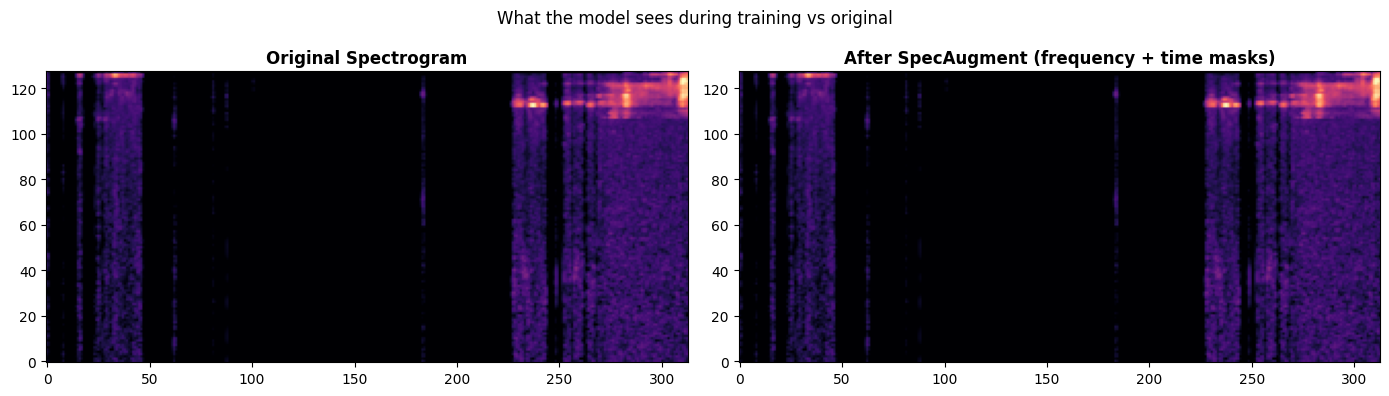

The masked patches (black bands) force the model to use other frequency regions.


In [25]:
folder = os.listdir(f"{GENRE_PATH}/jazz")[0]
y_ex, _ = librosa.load(f"{GENRE_PATH}/jazz/{folder}/vocals.wav", sr=SR, duration=10, mono=True)
mel_ex  = librosa.power_to_db(librosa.feature.melspectrogram(y=y_ex, sr=SR, n_mels=128), ref=np.max)
mel_tensor = torch.tensor(mel_ex.T)   # (time, freq)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(mel_ex, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("Original Spectrogram", fontweight="bold")

augmented = spec_augment(mel_tensor).numpy().T
axes[1].imshow(augmented, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("After SpecAugment (frequency + time masks)", fontweight="bold")

plt.suptitle("What the model sees during training vs original", fontsize=12)
plt.tight_layout(); plt.show()
print("The masked patches (black bands) force the model to use other frequency regions.")

**Why this helps:** If the model can only see part of the spectrogram, it can't just memorise "hip-hop always has energy at 80Hz".
It has to learn *robust* features that work even when parts are hidden.

## Part 4 — Shared Training Infrastructure
One set of training functions, reused by all 3 models.
No code duplication — just pass the model and dataloader.

### 4.1 Loss function and metric

In [26]:
# CrossEntropyLoss with label_smoothing=0.1:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

f1_metric = MulticlassF1Score(num_classes=N_LABELS, average="macro").to(DEVICE)

scaler = GradScaler(enabled=USE_AMP)

print("Loss, metric, scaler ready")

Loss, metric, scaler ready


### 4.2 Training loop (one epoch)

In [27]:
def train_epoch(model, dataloader, optimizer, scheduler):
    model.train()
    total_loss = 0

    for step, batch in enumerate(dataloader):
        inputs = batch["input_values"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        with autocast(enabled=USE_AMP):          # lower precision → faster
            loss = criterion(model(inputs).logits, labels) / GRAD_ACC

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACC == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent explosions
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if scheduler: scheduler.step()

        total_loss += loss.item() * GRAD_ACC
    return total_loss / len(dataloader)

print("train_epoch ready")

train_epoch ready


### 4.3 Validation loop (one epoch)

In [28]:
def val_epoch(model, dataloader):
    # Evaluate on validation set. Returns Macro F1 score.
    model.eval()
    f1_metric.reset()

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_values"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                logits = model(inputs).logits
            f1_metric.update(logits, labels)

    return f1_metric.compute().item()

print("val_epoch ready")

val_epoch ready


### 4.4 Two-Phase Training Strategy
We use this for all 3 models. Here's the reasoning:

```
Phase 1 (frozen backbone, 2 epochs, LR=3e-4)
  └─ The pre-trained model already knows audio features
  └─ We only train the new 10-class head
  └─ Fast, avoids catastrophic forgetting

Phase 2 (full model, 3 epochs, LR=1e-5)
  └─ Now fine-tune everything — very carefully
  └─ 10× lower LR so we don't erase AudioSet knowledge
  └─ Resume from best Phase 1 checkpoint
```

---
## Part 5 — Model 1: AST (Audio Spectrogram Transformer)
**Why AST?** EDA Q4 showed genres are visually distinct in spectrograms. AST converts audio to a 2D spectrogram and treats it like an image — perfect fit.
**Why 60% ensemble weight?** It was pre-trained on AudioSet (2M audio clips) — the largest audio pre-training dataset available.

### 5.1 Load pre-trained AST

In [29]:
ast_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

ast_model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=N_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(DEVICE)

print(f"AST loaded on {DEVICE}")


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AST loaded on cuda


### 5.2 AST Training Dataset
Implements the preprocessing decisions from Part 3:
- Random balanced sampling (EDA Q1)
- `vocals×0.5 + drums×0.3 + bass×0.2` mix (EDA Q2)
- Random crop (EDA Q6)
- SpecAugment (EDA Q4)

In [30]:
class ASTDataset(Dataset):
    def __init__(self, song_idx, extractor, size=TRAIN_SIZE):
        self.song_idx  = song_idx
        self.extractor = extractor
        self.size      = size

    def __len__(self): return self.size

    def __getitem__(self, _):
        genre     = random.choice(GENRES)                        # balanced: EDA Q1
        song_path = random.choice(self.song_idx[genre])

        v = load_audio(f"{song_path}/vocals.wav")
        d = load_audio(f"{song_path}/drums.wav")
        b = load_audio(f"{song_path}/bass.wav")
        audio = normalize(v * 0.5 + d * 0.3 + b * 0.2)

        audio = crop_random(audio)                               # random crop: EDA Q6
        inp   = self.extractor(audio, sampling_rate=SR, return_tensors="pt")
        x     = spec_augment(inp.input_values.squeeze(0))       # augment: EDA Q4

        return {"input_values": x, "labels": torch.tensor(label2id[genre])}

print("ASTDataset ready")

ASTDataset ready


### 5.3 AST Validation Dataset
Deterministic — center crop (EDA Q6), no augmentation (we need stable F1 scores).

In [31]:
class ASTValDataset(Dataset):
    def __init__(self, song_idx, extractor):
        self.extractor = extractor
        self.samples   = [(p, g) for g in GENRES for p in song_idx[g]]

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        song_path, genre = self.samples[i]
        v = load_audio(f"{song_path}/vocals.wav")
        d = load_audio(f"{song_path}/drums.wav")
        b = load_audio(f"{song_path}/bass.wav")
        audio = normalize(v * 0.5 + d * 0.3 + b * 0.2)
        audio = crop_center(audio)                               # center crop: EDA Q6
        inp   = self.extractor(audio, sampling_rate=SR, return_tensors="pt")
        return {"input_values": inp.input_values.squeeze(0), "labels": torch.tensor(label2id[genre])}

print("ASTValDataset ready")

ASTValDataset ready


### 5.4 AST DataLoaders

In [32]:
ast_train_dl = DataLoader(ASTDataset(train_idx, ast_extractor),
    batch_size=BATCH, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)

ast_val_dl = DataLoader(ASTValDataset(val_idx, ast_extractor),
    batch_size=BATCH * 2, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)

print(f"AST DataLoaders — Train: {len(ast_train_dl)} batches | Val: {len(ast_val_dl)} batches")

AST DataLoaders — Train: 125 batches | Val: 5 batches


### 5.5 AST Phase 1 — Warm up head only

In [33]:
for param in ast_model.base_model.parameters():
    param.requires_grad = False

opt1   = torch.optim.AdamW(filter(lambda p: p.requires_grad, ast_model.parameters()), lr=LR1)
sched1 = get_cosine_schedule_with_warmup(opt1, 50, len(ast_train_dl) * EP1 // GRAD_ACC)

best_p1     = 0
ast_history = {"loss": [], "f1": []}

for ep in range(EP1):
    loss = train_epoch(ast_model, ast_train_dl, opt1, sched1)
    f1   = val_epoch(ast_model, ast_val_dl)
    ast_history["loss"].append(loss); ast_history["f1"].append(f1)
    print(f"  AST P1 Epoch {ep+1}/{EP1} — loss: {loss:.4f}  val F1: {f1:.4f}")
    if f1 > best_p1:
        best_p1 = f1
        torch.save(ast_model.state_dict(), f"{OUTPUT_DIR}/ast_p1.pth")
        print(f"    Checkpoint saved (F1={best_p1:.4f})")

  AST P1 Epoch 1/2 — loss: 1.6598  val F1: 0.7134
    Checkpoint saved (F1=0.7134)
  AST P1 Epoch 2/2 — loss: 1.0827  val F1: 0.7307
    Checkpoint saved (F1=0.7307)


### 5.6 AST Phase 2 — Fine-tune entire model

In [34]:
ast_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/ast_p1.pth"))
for param in ast_model.parameters():
    param.requires_grad = True   # unfreeze everything

opt2 = torch.optim.AdamW([
    {"params": ast_model.base_model.parameters(),  "lr": LR2},
    {"params": ast_model.classifier.parameters(),  "lr": LR2 * 10}
])
sched2 = get_cosine_schedule_with_warmup(opt2, 100, len(ast_train_dl) * EP2 // GRAD_ACC)

best_ast       = 0
ast_p2_history = {"loss": [], "f1": []}

for ep in range(EP2):
    loss = train_epoch(ast_model, ast_train_dl, opt2, sched2)
    f1   = val_epoch(ast_model, ast_val_dl)
    ast_p2_history["loss"].append(loss); ast_p2_history["f1"].append(f1)
    print(f"  AST P2 Epoch {ep+1}/{EP2} — loss: {loss:.4f}  val F1: {f1:.4f}")
    if f1 > best_ast:
        best_ast = f1
        torch.save(ast_model.state_dict(), f"{OUTPUT_DIR}/ast_best.pth")
        print(f"    Best AST saved (F1={best_ast:.4f})")

print(f"\nAST done! Best Val F1 = {best_ast:.4f}")

# Free GPU memory before loading HuBERT
import gc
ast_model = ast_model.cpu()
del ast_train_dl, ast_val_dl
torch.cuda.empty_cache()
gc.collect()
print(f"AST moved to CPU. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

  AST P2 Epoch 1/3 — loss: 0.9486  val F1: 0.8130
    Best AST saved (F1=0.8130)
  AST P2 Epoch 2/3 — loss: 0.7205  val F1: 0.8580
    Best AST saved (F1=0.8580)
  AST P2 Epoch 3/3 — loss: 0.6220  val F1: 0.8649
    Best AST saved (F1=0.8649)

AST done! Best Val F1 = 0.8649
AST moved to CPU. GPU free: 13.1 GB


### AST Training Loss (did it decrease steadily?)

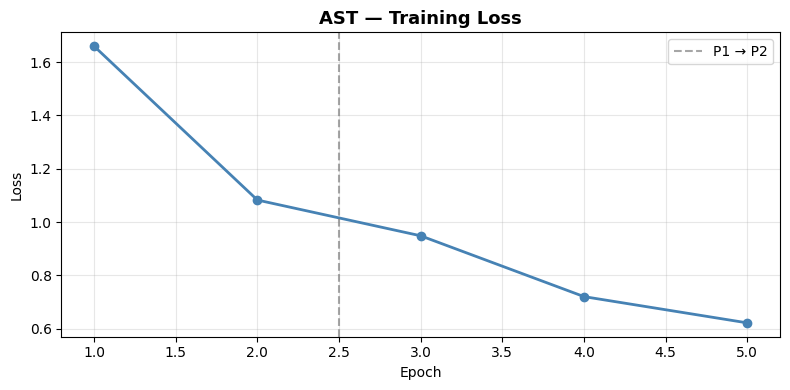

In [35]:
all_loss = ast_history["loss"] + ast_p2_history["loss"]
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(all_loss)+1), all_loss, "o-", color="steelblue", linewidth=2)
plt.axvline(EP1 + 0.5, color="gray", linestyle="--", alpha=0.7, label="P1 → P2")
plt.title("AST — Training Loss", fontsize=13, fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### AST Validation F1 (is it improving?)

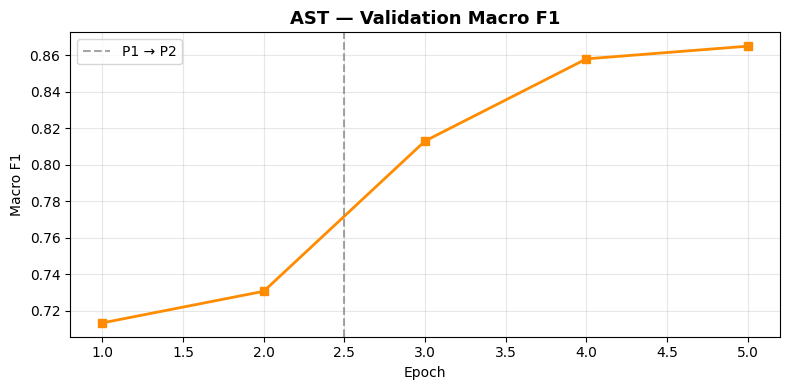

In [36]:
all_f1 = ast_history["f1"] + ast_p2_history["f1"]
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(all_f1)+1), all_f1, "s-", color="darkorange", linewidth=2)
plt.axvline(EP1 + 0.5, color="gray", linestyle="--", alpha=0.7, label="P1 → P2")
plt.title("AST — Validation Macro F1", fontsize=13, fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("Macro F1"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.7 Test-Time Augmentation — from EDA Q6 finding

In [37]:
def tta_predict(model, extractor, audio, n=N_TTA):
    crops = [extractor(crop_random(audio), sampling_rate=SR, return_tensors="pt")
             .input_values.to(DEVICE, non_blocking=True) for _ in range(n)]
    batch  = torch.cat(crops, dim=0)
    with torch.no_grad(), autocast(enabled=USE_AMP):
        logits = model(batch).logits
    probs = F.softmax(logits, dim=-1).float().cpu().numpy()
    return probs.mean(axis=0)   # average across N crops

print(f"TTA ready (n={N_TTA} crops)")

TTA ready (n=3 crops)


---
## Part 6 — Model 2: HuBERT
**Why HuBERT?** It's trained on raw waveforms rather than spectrograms — learns *different* features than AST.
When two models learn differently, combining them reduces errors. That's the power of ensembling.
**Why 20% weight?** Slightly weaker than AST on this task, but its diversity helps.

### 6.1 Load HuBERT

In [38]:
hub_proc  = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
hub_model = HubertForSequenceClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=N_LABELS, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True
).to(DEVICE)
print(f"HuBERT loaded on {DEVICE}")


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


HuBERT loaded on cuda


### 6.2 Shared Dataset for HuBERT and Wav2Vec2
*Both use the same API — no duplication needed.*

In [39]:
class SimpleDataset(Dataset):
    def __init__(self, song_idx, processor, size=3000):
        self.song_idx  = song_idx
        self.processor = processor
        self.size      = size

    def __len__(self): return self.size

    def __getitem__(self, _):
        genre     = random.choice(GENRES)
        song_path = random.choice(self.song_idx[genre])
        v = load_audio(f"{song_path}/vocals.wav")
        b = load_audio(f"{song_path}/bass.wav")
        audio = normalize(crop_random(v * 0.7 + b * 0.3))
        inp   = self.processor(audio, sampling_rate=SR, return_tensors="pt", padding=True)
        return {"input_values": inp.input_values.squeeze(0), "labels": torch.tensor(label2id[genre])}

print("SimpleDataset ready (shared for HuBERT and Wav2Vec2)")

SimpleDataset ready (shared for HuBERT and Wav2Vec2)


### 6.3 HuBERT DataLoaders

In [40]:
hub_train_dl = DataLoader(SimpleDataset(train_idx, hub_proc, 2000),
    batch_size=8, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
hub_val_dl   = DataLoader(SimpleDataset(val_idx, hub_proc, 300),
    batch_size=16, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
print(f"HuBERT — Train: {len(hub_train_dl)} batches | Val: {len(hub_val_dl)} batches")

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT — Train: 250 batches | Val: 19 batches


### 6.4 HuBERT Phase 1 + Phase 2

In [41]:
hub_crit   = nn.CrossEntropyLoss(label_smoothing=0.1)
hub_f1m    = MulticlassF1Score(num_classes=N_LABELS, average="macro").to(DEVICE)
hub_scaler = GradScaler(enabled=USE_AMP)

def hub_val():
    hub_model.eval(); hub_f1m.reset()
    with torch.no_grad():
        for b in hub_val_dl:
            with autocast(enabled=USE_AMP):
                logits = hub_model(b["input_values"].to(DEVICE, non_blocking=True)).logits
            hub_f1m.update(logits, b["labels"].to(DEVICE, non_blocking=True))
    return hub_f1m.compute().item()

for p in hub_model.hubert.parameters(): p.requires_grad = False
opt_h1   = torch.optim.AdamW(filter(lambda p: p.requires_grad, hub_model.parameters()), lr=3e-4)
best_hub = 0; hub_history = {"f1": []}

for ep in range(2):
    hub_model.train()
    for batch in tqdm(hub_train_dl, desc=f"HuBERT P1 ep{ep+1}", leave=False):
        with autocast(enabled=USE_AMP):
            loss = hub_crit(hub_model(batch["input_values"].to(DEVICE, non_blocking=True)).logits,
                            batch["labels"].to(DEVICE, non_blocking=True))
        hub_scaler.scale(loss).backward()
        hub_scaler.step(opt_h1); hub_scaler.update(); opt_h1.zero_grad(set_to_none=True)
    vf = hub_val(); hub_history["f1"].append(vf)
    print(f"  HuBERT P1 Epoch {ep+1}/2 — val F1: {vf:.4f}")
    if vf > best_hub:
        best_hub = vf; torch.save(hub_model.state_dict(), f"{OUTPUT_DIR}/hub_best.pth")
        print(f"    Saved (F1={best_hub:.4f})")

HuBERT P1 ep1:   0%|          | 0/250 [00:00<?, ?it/s]

  HuBERT P1 Epoch 1/2 — val F1: 0.4559
    Saved (F1=0.4559)


HuBERT P1 ep2:   0%|          | 0/250 [00:00<?, ?it/s]

  HuBERT P1 Epoch 2/2 — val F1: 0.5249
    Saved (F1=0.5249)


In [42]:
hub_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/hub_best.pth"))
for p in hub_model.parameters(): p.requires_grad = True
opt_h2 = torch.optim.AdamW(hub_model.parameters(), lr=1e-5)

for ep in range(3):
    hub_model.train()
    for batch in tqdm(hub_train_dl, desc=f"HuBERT P2 ep{ep+1}", leave=False):
        with autocast(enabled=USE_AMP):
            loss = hub_crit(hub_model(batch["input_values"].to(DEVICE, non_blocking=True)).logits,
                            batch["labels"].to(DEVICE, non_blocking=True))
        hub_scaler.scale(loss).backward()
        hub_scaler.step(opt_h2); hub_scaler.update(); opt_h2.zero_grad(set_to_none=True)
    vf = hub_val(); hub_history["f1"].append(vf)
    print(f"  HuBERT P2 Epoch {ep+1}/3 — val F1: {vf:.4f}")
    if vf > best_hub:
        best_hub = vf; torch.save(hub_model.state_dict(), f"{OUTPUT_DIR}/hub_best.pth")
        print(f"    Saved (F1={best_hub:.4f})")
print(f"\nHuBERT done! Best Val F1 = {best_hub:.4f}")

# Free GPU memory before loading Wav2Vec2
import gc
hub_model = hub_model.cpu()
del hub_train_dl, hub_val_dl
torch.cuda.empty_cache()
gc.collect()
print(f"HuBERT moved to CPU. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

HuBERT P2 ep1:   0%|          | 0/250 [00:00<?, ?it/s]

  HuBERT P2 Epoch 1/3 — val F1: 0.5707
    Saved (F1=0.5707)


HuBERT P2 ep2:   0%|          | 0/250 [00:00<?, ?it/s]

  HuBERT P2 Epoch 2/3 — val F1: 0.6073
    Saved (F1=0.6073)


HuBERT P2 ep3:   0%|          | 0/250 [00:00<?, ?it/s]

  HuBERT P2 Epoch 3/3 — val F1: 0.6887
    Saved (F1=0.6887)

HuBERT done! Best Val F1 = 0.6887
HuBERT moved to CPU. GPU free: 11.4 GB


### HuBERT Validation F1

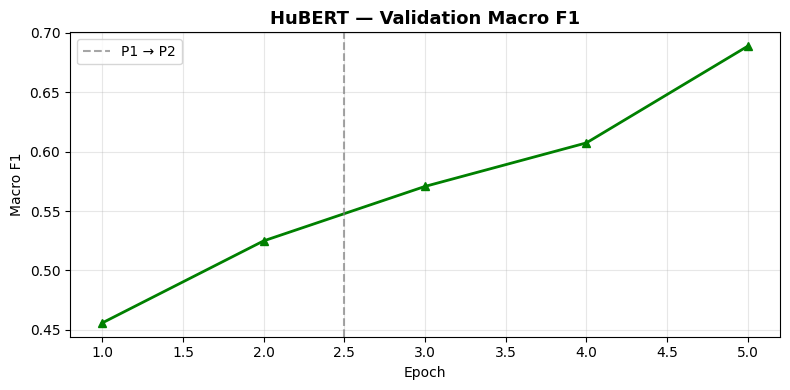

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(hub_history["f1"])+1), hub_history["f1"], "^-", color="green", linewidth=2)
plt.axvline(2.5, color="gray", linestyle="--", alpha=0.7, label="P1 → P2")
plt.title("HuBERT — Validation Macro F1", fontsize=13, fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("Macro F1"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Part 7 — Model 3: Wav2Vec2
**Why Wav2Vec2?** Uses contrastive learning — a different pre-training objective than HuBERT.
Slightly different representations → even more diverse ensemble.
**Why 20% weight?** Similar strength to HuBERT.

### 7.1 Load Wav2Vec2

In [44]:
w2v_proc  = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
w2v_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=N_LABELS, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True
).to(DEVICE)
print(f"Wav2Vec2 loaded on {DEVICE}")


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2 loaded on cuda


### 7.2 Wav2Vec2 DataLoaders (reuses SimpleDataset)

In [45]:
w2v_train_dl = DataLoader(SimpleDataset(train_idx, w2v_proc, 2000),
    batch_size=8, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
w2v_val_dl   = DataLoader(SimpleDataset(val_idx, w2v_proc, 300),
    batch_size=16, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
print(f"Wav2Vec2 — Train: {len(w2v_train_dl)} batches | Val: {len(w2v_val_dl)} batches")

Wav2Vec2 — Train: 250 batches | Val: 19 batches


### 7.3 Wav2Vec2 Phase 1 + Phase 2

In [46]:
w2v_crit   = nn.CrossEntropyLoss(label_smoothing=0.1)
w2v_f1m    = MulticlassF1Score(num_classes=N_LABELS, average="macro").to(DEVICE)
w2v_scaler = GradScaler(enabled=USE_AMP)

def w2v_val():
    w2v_model.eval(); w2v_f1m.reset()
    with torch.no_grad():
        for b in w2v_val_dl:
            with autocast(enabled=USE_AMP):
                logits = w2v_model(b["input_values"].to(DEVICE, non_blocking=True)).logits
            w2v_f1m.update(logits, b["labels"].to(DEVICE, non_blocking=True))
    return w2v_f1m.compute().item()

for p in w2v_model.wav2vec2.parameters(): p.requires_grad = False
opt_w1   = torch.optim.AdamW(filter(lambda p: p.requires_grad, w2v_model.parameters()), lr=3e-4)
best_w2v = 0; w2v_history = {"f1": []}

for ep in range(2):
    w2v_model.train()
    for batch in tqdm(w2v_train_dl, desc=f"W2V P1 ep{ep+1}", leave=False):
        with autocast(enabled=USE_AMP):
            loss = w2v_crit(w2v_model(batch["input_values"].to(DEVICE, non_blocking=True)).logits,
                            batch["labels"].to(DEVICE, non_blocking=True))
        w2v_scaler.scale(loss).backward()
        w2v_scaler.step(opt_w1); w2v_scaler.update(); opt_w1.zero_grad(set_to_none=True)
    vf = w2v_val(); w2v_history["f1"].append(vf)
    print(f"  W2V P1 Epoch {ep+1}/2 — val F1: {vf:.4f}")
    if vf > best_w2v:
        best_w2v = vf; torch.save(w2v_model.state_dict(), f"{OUTPUT_DIR}/w2v_best.pth")
        print(f"    Saved (F1={best_w2v:.4f})")

W2V P1 ep1:   0%|          | 0/250 [00:00<?, ?it/s]

  W2V P1 Epoch 1/2 — val F1: 0.4403
    Saved (F1=0.4403)


W2V P1 ep2:   0%|          | 0/250 [00:00<?, ?it/s]

  W2V P1 Epoch 2/2 — val F1: 0.5053
    Saved (F1=0.5053)


In [47]:
w2v_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/w2v_best.pth"))
for p in w2v_model.parameters(): p.requires_grad = True
opt_w2 = torch.optim.AdamW(w2v_model.parameters(), lr=1e-5)

for ep in range(3):
    w2v_model.train()
    for batch in tqdm(w2v_train_dl, desc=f"W2V P2 ep{ep+1}", leave=False):
        with autocast(enabled=USE_AMP):
            loss = w2v_crit(w2v_model(batch["input_values"].to(DEVICE, non_blocking=True)).logits,
                            batch["labels"].to(DEVICE, non_blocking=True))
        w2v_scaler.scale(loss).backward()
        w2v_scaler.step(opt_w2); w2v_scaler.update(); opt_w2.zero_grad(set_to_none=True)
    vf = w2v_val(); w2v_history["f1"].append(vf)
    print(f"  W2V P2 Epoch {ep+1}/3 — val F1: {vf:.4f}")
    if vf > best_w2v:
        best_w2v = vf; torch.save(w2v_model.state_dict(), f"{OUTPUT_DIR}/w2v_best.pth")
        print(f"    Saved (F1={best_w2v:.4f})")
print(f"\nWav2Vec2 done! Best Val F1 = {best_w2v:.4f}")

# Free GPU memory
import gc
w2v_model = w2v_model.cpu()
del w2v_train_dl, w2v_val_dl
torch.cuda.empty_cache()
gc.collect()
print(f"Wav2Vec2 moved to CPU. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

W2V P2 ep1:   0%|          | 0/250 [00:00<?, ?it/s]

  W2V P2 Epoch 1/3 — val F1: 0.5383
    Saved (F1=0.5383)


W2V P2 ep2:   0%|          | 0/250 [00:00<?, ?it/s]

  W2V P2 Epoch 2/3 — val F1: 0.6770
    Saved (F1=0.6770)


W2V P2 ep3:   0%|          | 0/250 [00:00<?, ?it/s]

  W2V P2 Epoch 3/3 — val F1: 0.6805
    Saved (F1=0.6805)

Wav2Vec2 done! Best Val F1 = 0.6805
Wav2Vec2 moved to CPU. GPU free: 10.3 GB


### Wav2Vec2 Validation F1

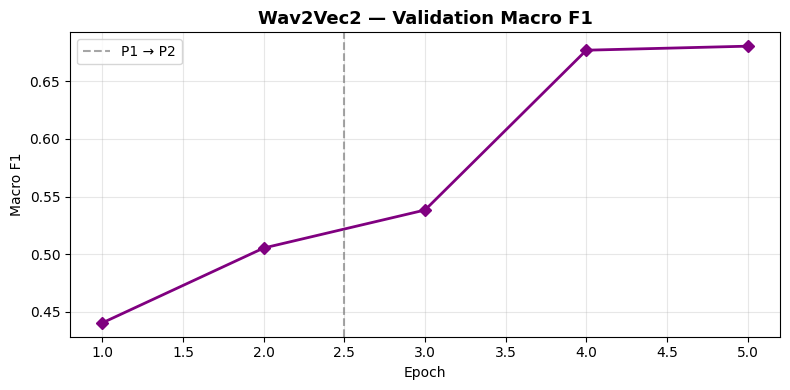

In [48]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(w2v_history["f1"])+1), w2v_history["f1"], "D-", color="purple", linewidth=2)
plt.axvline(2.5, color="gray", linestyle="--", alpha=0.7, label="P1 → P2")
plt.title("Wav2Vec2 — Validation Macro F1", fontsize=13, fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("Macro F1"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Part 8 — Ensemble + Submission
We combine all 3 models by **weighted probability averaging**.

Why these weights (60/20/20)? AST has the strongest single-model score (it was trained on the most audio data).
HuBERT and Wav2Vec2 add complementary features — their predictions differ enough from AST to be useful.

### Model Comparison — which model performed best?

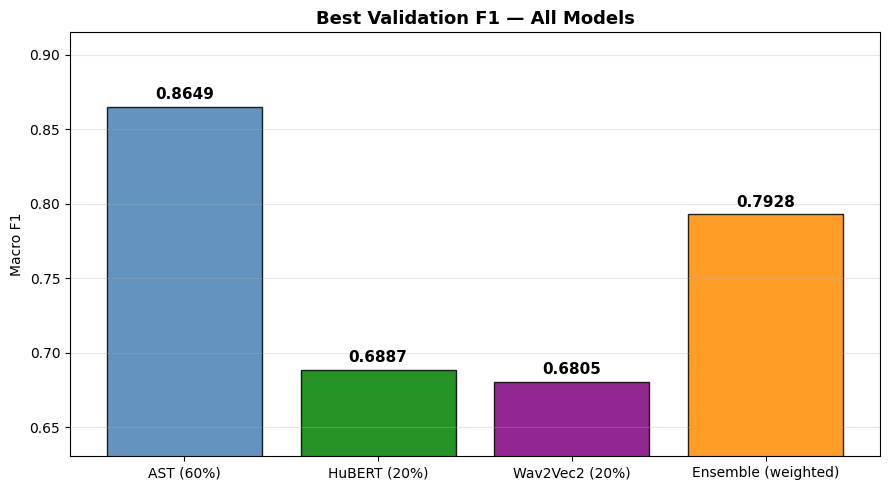

In [50]:
ens_est = 0.6*best_ast + 0.2*best_hub + 0.2*best_w2v
scores  = [best_ast, best_hub, best_w2v, ens_est]
names   = ["AST (60%)", "HuBERT (20%)", "Wav2Vec2 (20%)", "Ensemble (weighted)"]
colors  = ["steelblue", "green", "purple", "darkorange"]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, scores, color=colors, alpha=0.85, edgecolor="black")
plt.ylim(max(0, min(scores)-0.05), min(1.0, max(scores)+0.05))
for bar, val in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.003,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Best Validation F1 — All Models", fontsize=13, fontweight="bold")
plt.ylabel("Macro F1"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

### 8.1 Load best checkpoints

In [51]:
# Load all best weights back onto GPU for inference
ast_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/ast_best.pth", map_location="cpu"))
hub_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/hub_best.pth", map_location="cpu"))
w2v_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/w2v_best.pth", map_location="cpu"))

ast_model = ast_model.to(DEVICE)
hub_model = hub_model.to(DEVICE)
w2v_model = w2v_model.to(DEVICE)

ast_model.eval(); hub_model.eval(); w2v_model.eval()
print(f"All models loaded. GPU: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB free")

All models loaded. GPU: 10.3 GB free


### 8.2 Ensemble predict function

In [52]:
def ensemble_predict(audio):
    ast_probs = tta_predict(ast_model, ast_extractor, audio)

    crop  = crop_random(audio)
    h_inp = hub_proc(crop, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, non_blocking=True)
    w_inp = w2v_proc(crop, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, non_blocking=True)

    with torch.no_grad(), autocast(enabled=USE_AMP):
        hub_probs = F.softmax(hub_model(h_inp).logits, dim=-1).float().cpu().numpy()[0]
        w2v_probs = F.softmax(w2v_model(w_inp).logits, dim=-1).float().cpu().numpy()[0]

    # Weighted average: AST 60%, HuBERT 20%, Wav2Vec2 20%
    combined = 0.6*ast_probs + 0.2*hub_probs + 0.2*w2v_probs
    return GENRES[combined.argmax()]

print("ensemble_predict ready")

ensemble_predict ready


### 8.3 Run inference on test set → save submission.csv

In [53]:
test_csv_path = f"{BASE}/test.csv"
if not os.path.exists(test_csv_path):
    raise FileNotFoundError(f"test.csv not found at {test_csv_path}")

test_df = pd.read_csv(test_csv_path)
print(f"Test set: {len(test_df)} samples")

ids, preds = [], []
for i in tqdm(range(len(test_df)), desc="Predicting"):
    row   = test_df.iloc[i]
    audio = load_audio(f"{BASE}/{row.filename}")
    preds.append(ensemble_predict(audio))
    ids.append(row.id)

sub = pd.DataFrame({"id": ids, "genre": preds})
sub.to_csv(f"{OUTPUT_DIR}/submission.csv", index=False)
print(f"\nsubmission.csv saved — {sub.shape[0]} rows")

Test set: 3020 samples


Predicting:   0%|          | 0/3020 [00:00<?, ?it/s]


submission.csv saved — 3020 rows


### What did we predict? Genre distribution check

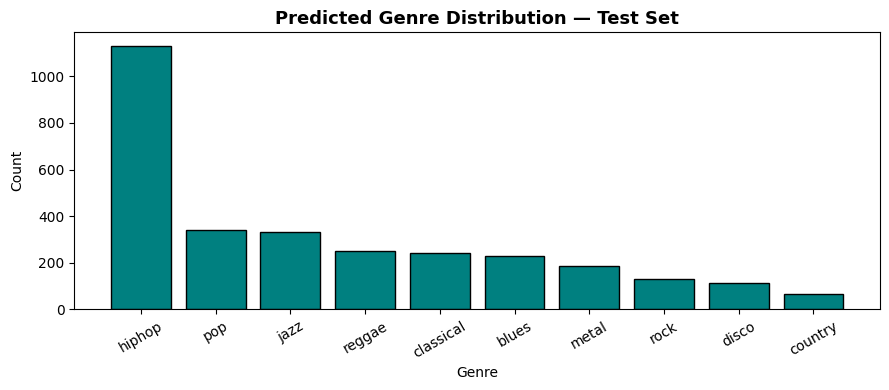

genre
hiphop       1132
pop           342
jazz          333
reggae        251
classical     240
blues         227
metal         188
rock          130
disco         113
country        64
Name: count, dtype: int64

💡 If one genre dominates massively, something may be wrong with the model.


In [59]:
sub = pd.read_csv(f"{OUTPUT_DIR}/submission.csv")
counts_pred = sub["genre"].value_counts()

plt.figure(figsize=(9, 4))
plt.bar(counts_pred.index, counts_pred.values, color="teal", edgecolor="black")
plt.title("Predicted Genre Distribution — Test Set", fontsize=13, fontweight="bold")
plt.xlabel("Genre"); plt.ylabel("Count"); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()
print(counts_pred)
print("\n If one genre dominates massively, something may be wrong with the model.")

### 8.4 Final verification + summary

In [71]:
import os

sub_path = f"{OUTPUT_DIR}/submission.csv"
print("=" * 50)
print("  MUSIC GENRE CLASSIFIER — DONE")
print("=" * 50)
print(f"  AST     best Val F1  : {best_ast:.4f}  (60% weight)")
print(f"  HuBERT  best Val F1  : {best_hub:.4f}  (20% weight)")
print(f"  Wav2Vec2 best Val F1 : {best_w2v:.4f}  (20% weight)")
print("=" * 50)
if os.path.exists(sub_path):
    df = pd.read_csv(sub_path)
    print(f"  submission.csv found — {len(df)} predictions")
    print(f"  Upload submission.csv to Kaggle!")
else:
    print("  submission.csv NOT found — re-run inference cell")

  MUSIC GENRE CLASSIFIER — DONE
  AST     best Val F1  : 0.8649  (60% weight)
  HuBERT  best Val F1  : 0.6887  (20% weight)
  Wav2Vec2 best Val F1 : 0.6805  (20% weight)
  submission.csv found — 3020 predictions
  Upload submission.csv to Kaggle!
